In [1]:
%load_ext autoreload
%autoreload 2
%load_ext autotime
    
import pickle
import numpy as np
import matplotlib.pyplot as plt

time: 531 ms (started: 2025-05-15 21:42:48 +08:00)


In [2]:
with open('fig3_data.pkl', 'rb') as f:
    fig3_data = pickle.load(f)
reference_field_img = fig3_data['panel1_data']['reference_field_img']
potential_field_img = fig3_data['panel1_data']['potential_field_img']
generated_field_img = fig3_data['panel1_data']['generated_field_img']
retrained_field_img = fig3_data['panel1_data']['retrained_field_img']
fi_ref = fig3_data['panel2_data']['fi_ref']
Ji_ref = fig3_data['panel2_data']['Ji_ref']
th_ref = fig3_data['panel2_data']['th_ref']
fi_gen = fig3_data['panel2_data']['fi_gen']
Ji_gen = fig3_data['panel2_data']['Ji_gen']
th_gen = fig3_data['panel2_data']['th_gen']
fi_ret = fig3_data['panel2_data']['fi_ret']
Ji_ret = fig3_data['panel2_data']['Ji_ret']
th_ret = fig3_data['panel2_data']['th_ret']

time: 117 ms (started: 2025-05-15 21:43:19 +08:00)


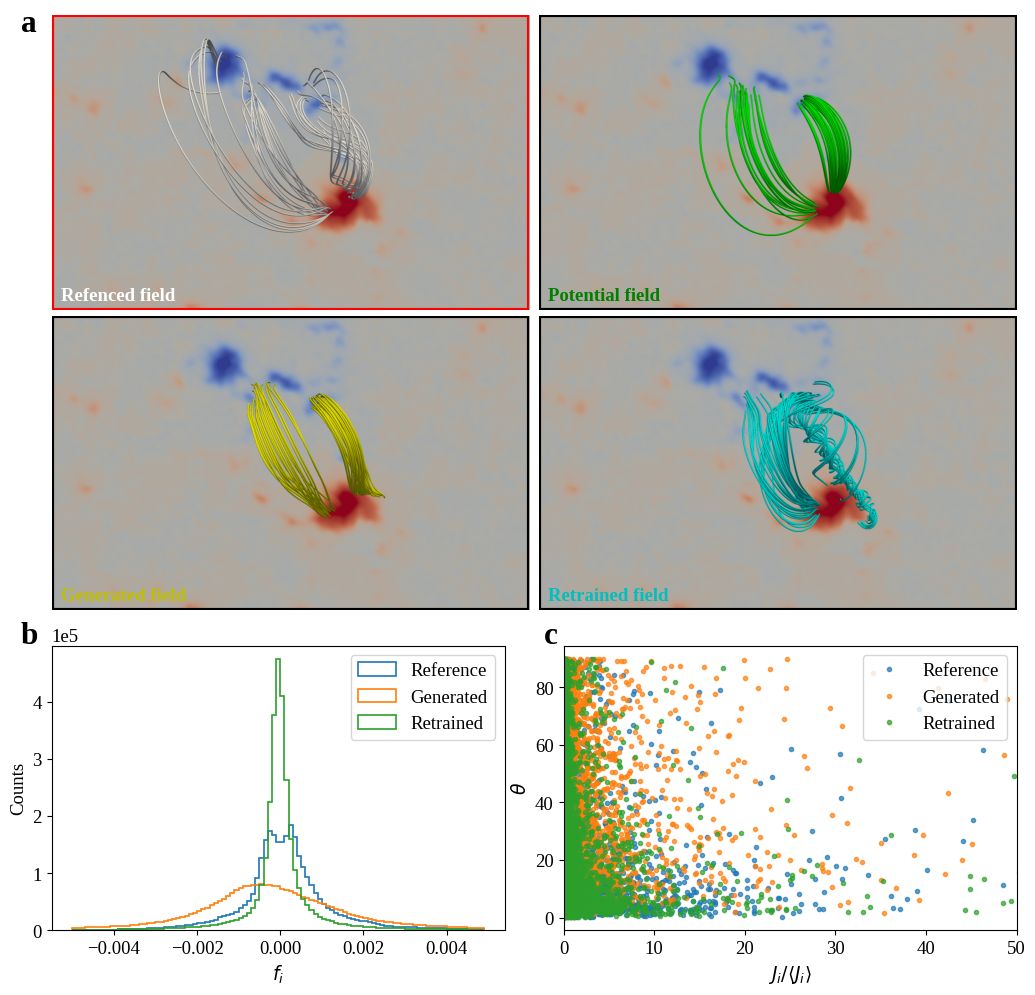

time: 9.78 s (started: 2025-05-15 21:43:33 +08:00)


In [3]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
from numpy.linalg import norm

zoom_factor = 1.5
plt.rcParams['font.size'] = 9.0*zoom_factor
plt.rcParams['font.family']='Liberation Serif'
A4_width = 8.3*zoom_factor
A4_length = 11.7*zoom_factor
golden_ratio = 0.618
img_ratio = reference_field_img.shape[0]/reference_field_img.shape[1]

plot_height = A4_width*(golden_ratio/2+img_ratio)
fig = plt.figure(figsize=(A4_width, plot_height))

gs = gridspec.GridSpec(2, 1, height_ratios=[img_ratio, golden_ratio/2])

gs0 = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs[0], wspace=0.02, hspace=0.02)
ax = fig.add_subplot(gs0[0])
height,width = reference_field_img.shape[:2]
border_width  = 3
border_color  = 'red'
plt.imshow(reference_field_img, aspect='auto')
plt.axis('off')
plt.text(0.02,0.02,'Refenced field',transform=plt.gca().transAxes,ha='left',va='bottom',fontsize=9.0*zoom_factor, color='white',fontweight='bold')
rect = patches.Rectangle((0,0), width, height, linewidth=border_width, edgecolor=border_color, facecolor='none')
plt.gca().add_patch(rect)

ax = fig.add_subplot(gs0[1])
plt.imshow(potential_field_img, aspect='auto')
plt.text(0.02,0.02,'Potential field',transform=plt.gca().transAxes,ha='left',va='bottom',fontsize=9.0*zoom_factor, color='green',fontweight='bold')
plt.axis('off')
border_width  = 3
border_color  = 'black'
rect = patches.Rectangle((0,0), width, height, linewidth=border_width, edgecolor=border_color, facecolor='none')
plt.gca().add_patch(rect)

ax = fig.add_subplot(gs0[2])
plt.imshow(generated_field_img, aspect='auto')
plt.axis('off')
plt.text(0.02,0.02,'Generated field',transform=plt.gca().transAxes,ha='left',va='bottom',fontsize=9.0*zoom_factor, color='y',fontweight='bold')
border_width  = 3
border_color  = 'black'
rect = patches.Rectangle((0,0), width, height, linewidth=border_width, edgecolor=border_color, facecolor='none')
plt.gca().add_patch(rect)

ax = fig.add_subplot(gs0[3])
plt.imshow(retrained_field_img, aspect='auto')
plt.axis('off')
plt.text(0.02,0.02,'Retrained field',transform=plt.gca().transAxes,ha='left',va='bottom',fontsize=9.0*zoom_factor, color='c',fontweight='bold')
border_width  = 3
border_color  = 'black'
rect = patches.Rectangle((0,0), width, height, linewidth=border_width, edgecolor=border_color, facecolor='none')
plt.gca().add_patch(rect)

gs1 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[1], wspace=0.13, hspace=0.02)

ax = fig.add_subplot(gs1[0])

bins = np.arange(-0.005,0.005,0.0001)
plt.hist(fi_ref.flatten(),bins=bins, histtype='step', color='C0', linewidth=1.2,
         label=r'Reference')
plt.hist(fi_gen.flatten(),bins=bins, histtype='step', color='C1', linewidth=1.2,
         label=r'Generated')
plt.hist(fi_ret.flatten(),bins=bins, histtype='step', color='C2', linewidth=1.2,
         label=r'Retrained')
plt.ticklabel_format(axis='y', style='scientific', scilimits=(0,0))
plt.xlabel(r'$f_i$')
plt.ylabel('Counts')
plt.legend(loc='upper right')

ax = fig.add_subplot(gs1[1])
idx = np.random.choice(len(th_ref.flatten()),10000,replace=False)
temp_x = (norm(Ji_ref,axis=0)/norm(Ji_ref,axis=0).mean()).flatten()[idx]
temp_y = th_ref.flatten()[idx]
# plt.figure()
plt.plot(temp_x,temp_y,'.',c='C0',ls='',alpha=0.7,label='Reference')
temp_x = (norm(Ji_gen,axis=0)/norm(Ji_gen,axis=0).mean()).flatten()[idx]
temp_y = th_gen.flatten()[idx]
plt.plot(temp_x,temp_y,'.',c='C1',ls='',alpha=0.7,label='Generated')
temp_x = (norm(Ji_ret,axis=0)/norm(Ji_ret,axis=0).mean()).flatten()[idx]
temp_y = th_ret.flatten()[idx]
plt.plot(temp_x,temp_y,'.',c='C2',ls='',alpha=0.7,label='Retrained')
plt.xlim((0,50))
plt.xlabel(r'$J_i/\langle J_i\rangle$')
plt.ylabel(r'$\theta$')
plt.legend(loc='upper right')

xx = 0.10
ya = 0.885
yb = 0.370
fig.text(xx, ya, 'a', fontsize=15*zoom_factor, fontweight='bold', ha='left', va='top')
fig.text(xx, yb, 'b', fontsize=15*zoom_factor, fontweight='bold', ha='left', va='top')
fig.text(xx+0.42, yb, 'c', fontsize=15*zoom_factor, fontweight='bold', ha='left', va='top')
plt.savefig('fig3.png', dpi=400, bbox_inches='tight')
plt.savefig('fig3.pdf', dpi=400, bbox_inches='tight')
plt.subplots_adjust(hspace=0.08)
plt.show()